In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_excel(
    "/content/drive/MyDrive/smartphone_distraction.xlsx"
)

print(df.shape)
df.head()

(10000, 16)


,record_id,Age,Current occupation,"On average, how many hours do you spend on your smartphone per day?",Approximately how many times do you unlock/check your phone per day?,Approximately how many notifications do you receive per day?,"When you unlock your phone, how often do you find that there is actually NO new notification?",What percentage of your notifications are related to work/studies?,What percentage of your notifications are from entertainment/social-media apps?,Which type of notification usually makes you check your phone immediately?,During which period do you use your smartphone the most?,How often do you interrupt your study/work because of a phone notification?,How would you rate your ability to concentrate during study/work?,"After using your smartphone for a long period, how often do you feel that your productivity has decreased?",Do you currently use any digital-wellness features?,How effective do you think these features are in reducing your phone distractions?
0,1,18 - 30,Student,2–4 hours,41–60,More than 100,Sometimes,11–25%,51–75%,Social media,12 PM – 3 PM,Sometimes,6,Rarely,Other,5
1,2,18 - 30,Student,6–8 hours,41–60,Less than 20,Sometimes,11–25%,0–10%,Work/college,6 PM – 9 PM,Rarely,7,Sometimes,Screen-time monitoring,4
2,3,18 - 30,Student,More than 8 hours,20–40,20–50,Rarely,0–10%,11–25%,Work/college,9 PM – 12 AM,Often,7,Often,App limits,4
3,4,18 - 30,Working professional,6–8 hours,41–60,51–100,Rarely,76–100%,0–10%,Work/college,9 PM – 12 AM,Often,6,Sometimes,App limits,1
4,5,Above 30,Home maker,2–4 hours,Less than 20,20–50,Sometimes,11–25%,26–50%,Other,9 AM – 12 PM,Often,3,Rarely,Do Not Disturb,3


In [ ]:
print(df.shape)
print(df.columns.tolist())
print(df.info())

(10000, 16)
['record_id', 'Age', 'Current occupation', 'On average, how many hours do you spend on your smartphone per day?', 'Approximately how many times do you unlock/check your phone per day?', 'Approximately how many notifications do you receive per day?', 'When you unlock your phone, how often do you find that there is actually NO new notification?', 'What percentage of your notifications are related to work/studies?', 'What percentage of your notifications are from entertainment/social-media apps?', 'Which type of notification usually makes you check your phone immediately?', 'During which period do you use your smartphone the most?', 'How often do you interrupt your study/work because of a phone notification?', 'How would you rate your ability to concentrate during study/work?', 'After using your smartphone for a long period, how often do you feel that your productivity has decreased?', 'Do you currently use any digital-wellness features?', 'How effective do you think these fea

In [ ]:
df.isnull().sum()

,0
record_id,0
Age,0
Current occupation,0
"On average, how many hours do you spend on your smartphone per day?",0
Approximately how many times do you unlock/check your phone per day?,0
Approximately how many notifications do you receive per day?,0
"When you unlock your phone, how often do you find that there is actually NO new notification?",0
What percentage of your notifications are related to work/studies?,0
What percentage of your notifications are from entertainment/social-media apps?,0
Which type of notification usually makes you check your phone immediately?,0


In [ ]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [ ]:
#if duplicates, deleting them
df = df.drop_duplicates().reset_index(drop=True)
print("Final shape:", df.shape)

Final shape: (10000, 16)


In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("/", "_")
    .str.replace("(", "")
    .str.replace(")", "")
    .str.replace("%", "pct")
)

df.columns.tolist()

['record_id',
 'age',
 'current_occupation',
 'on_average,_how_many_hours_do_you_spend_on_your_smartphone_per_day?',
 'approximately_how_many_times_do_you_unlock_check_your_phone_per_day?',
 'approximately_how_many_notifications_do_you_receive_per_day?',
 'when_you_unlock_your_phone,_how_often_do_you_find_that_there_is_actually_no_new_notification?',
 'what_percentage_of_your_notifications_are_related_to_work_studies?',
 'what_percentage_of_your_notifications_are_from_entertainment_social-media_apps?',
 'which_type_of_notification_usually_makes_you_check_your_phone_immediately?',
 'during_which_period_do_you_use_your_smartphone_the_most?',
 'how_often_do_you_interrupt_your_study_work_because_of_a_phone_notification?',
 'how_would_you_rate_your_ability_to_concentrate_during_study_work?',
 'after_using_your_smartphone_for_a_long_period,_how_often_do_you_feel_that_your_productivity_has_decreased?',
 'do_you_currently_use_any_digital-wellness_features?',
 'how_effective_do_you_think_these_

In [ ]:
for c in df.columns:
    print("\n", c)
    print(df[c].value_counts(dropna=False).head(10))


 record_id
record_id
10000    1
1        1
2        1
3        1
4        1
5        1
6        1
7        1
8        1
9        1
Name: count, dtype: int64

 age
age
18 - 30     6726
Above 30    1846
Under 18    1428
Name: count, dtype: int64

 current_occupation
current_occupation
Student                 5764
Working professional    2738
Self-employed           1246
House wife               116
Home maker               114
Homemaker                 22
Name: count, dtype: int64

 on_average,_how_many_hours_do_you_spend_on_your_smartphone_per_day?
on_average,_how_many_hours_do_you_spend_on_your_smartphone_per_day?
4–6 hours            3465
2–4 hours            2695
6–8 hours            1719
Less than 2 hours    1123
More than 8 hours     998
Name: count, dtype: int64

 approximately_how_many_times_do_you_unlock_check_your_phone_per_day?
approximately_how_many_times_do_you_unlock_check_your_phone_per_day?
41–60            2663
20–40            2647
61–80            2050
Less than 20   

In [ ]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['record_id', 'age', 'current_occupation', 'on_average,_how_many_hours_do_you_spend_on_your_smartphone_per_day?', 'approximately_how_many_times_do_you_unlock_check_your_phone_per_day?', 'approximately_how_many_notifications_do_you_receive_per_day?', 'when_you_unlock_your_phone,_how_often_do_you_find_that_there_is_actually_no_new_notification?', 'what_percentage_of_your_notifications_are_related_to_work_studies?', 'what_percentage_of_your_notifications_are_from_entertainment_social-media_apps?', 'which_type_of_notification_usually_makes_you_check_your_phone_immediately?', 'during_which_period_do_you_use_your_smartphone_the_most?', 'how_often_do_you_interrupt_your_study_work_because_of_a_phone_notification?', 'how_would_you_rate_your_ability_to_concentrate_during_study_work?', 'after_using_your_smartphone_for_a_long_period,_how_often_do_you_feel_that_your_productivity_has_decreased?', 'do_you_currently_use_any_digital-wellness_features?', 'how_effective_do_you_think_these_features_are_in

In [ ]:
df = df.rename(columns={
    "Age": "age",
    "Current occupation": "occupation",
    "On average, how many hours do you spend on your smartphone per day?": "daily_screen_time",
    "Approximately how many times do you unlock/check your phone per day?": "daily_phone_checks",
    "Approximately how many notifications do you receive per day?": "daily_notifications",
    "When you unlock your phone, how often do you find that there is actually NO new notification?": "phantom_check",
    "What percentage of your notifications are related to work/studies?": "work_notification_pct",
    "social_notification_pct": "social_notification_pct",
    "Which type of notification usually makes you check your phone immediately?": "immediate_notification_type",
    "During which period do you use your smartphone the most?": "peak_usage_period",
    "How often do you interrupt your study/work because of a phone notification?": "work_interruption",
    "How would you rate your ability to concentrate during study/work?": "concentration",
    "After using your smartphone for a long period, how often do you feel that your productivity has decreased?": "productivity_decrease",
    "Do you currently use any digital-wellness features?": "digital_wellness",
    "How effective do you think these features are in reducing your phone distractions?": "wellness_effectiveness"
})

print(df.columns.tolist())

['record_id', 'age', 'current_occupation', 'on_average,_how_many_hours_do_you_spend_on_your_smartphone_per_day?', 'approximately_how_many_times_do_you_unlock_check_your_phone_per_day?', 'approximately_how_many_notifications_do_you_receive_per_day?', 'when_you_unlock_your_phone,_how_often_do_you_find_that_there_is_actually_no_new_notification?', 'what_percentage_of_your_notifications_are_related_to_work_studies?', 'what_percentage_of_your_notifications_are_from_entertainment_social-media_apps?', 'which_type_of_notification_usually_makes_you_check_your_phone_immediately?', 'during_which_period_do_you_use_your_smartphone_the_most?', 'how_often_do_you_interrupt_your_study_work_because_of_a_phone_notification?', 'how_would_you_rate_your_ability_to_concentrate_during_study_work?', 'after_using_your_smartphone_for_a_long_period,_how_often_do_you_feel_that_your_productivity_has_decreased?', 'do_you_currently_use_any_digital-wellness_features?', 'how_effective_do_you_think_these_features_are_in

In [ ]:
df = df.rename(columns={
    "on_average,_how_many_hours_do_you_spend_on_your_smartphone_per_day?": "screen_time",
    "approximately_how_many_times_do_you_unlock_check_your_phone_per_day?": "phone_checks",
    "approximately_how_many_notifications_do_you_receive_per_day?": "notifications",
    "when_you_unlock_your_phone,_how_often_do_you_find_that_there_is_actually_no_new_notification?": "phantom_check",
    "what_percentage_of_your_notifications_are_related_to_work_studies?": "work_notification_pct",
    "what_percentage_of_your_notifications_are_from_entertainment_social-media_apps?": "social_notification_pct",
    "how_often_do_you_interrupt_your_study_work_because_of_a_phone_notification?": "interruptions",
    "how_would_you_rate_your_ability_to_concentrate_during_study_work?": "concentration",
    "after_using_your_smartphone_for_a_long_period,_how_often_do_you_feel_that_your_productivity_has_decreased?": "productivity_decrease",
    "do_you_currently_use_any_digital-wellness_features?": "wellness_features",
    "how_effective_do_you_think_these_features_are_in_reducing_your_phone_distractions?": "wellness_effectiveness"
})

print(df.columns.tolist())

['record_id', 'age', 'current_occupation', 'screen_time', 'phone_checks', 'notifications', 'phantom_check', 'work_notification_pct', 'social_notification_pct', 'which_type_of_notification_usually_makes_you_check_your_phone_immediately?', 'during_which_period_do_you_use_your_smartphone_the_most?', 'interruptions', 'concentration', 'productivity_decrease', 'wellness_features', 'wellness_effectiveness']


In [ ]:
screen_map = {
    "Less than 2 hours": 1,
    "2–4 hours": 3,
    "4–6 hours": 5,
    "6–8 hours": 7,
    "More than 8 hours": 9
}

checks_map = {
    "Less than 20": 10,
    "20–40": 30,
    "41–60": 50,
    "61–80": 70,
    "81–100": 90,
    "More than 100": 110
}

notif_map = {
    "Less than 20": 10,
    "20–50": 35,
    "51–100": 75,
    "More than 100": 120
}

df["screen_time_num"] = df["screen_time"].map(screen_map)
df["phone_checks_num"] = df["phone_checks"].map(checks_map)
df["notifications_num"] = df["notifications"].map(notif_map)

print(df[
    [
        "screen_time",
        "screen_time_num",
        "phone_checks",
        "phone_checks_num",
        "notifications",
        "notifications_num"
    ]
].head(10))

         screen_time  screen_time_num  phone_checks  phone_checks_num  \
0          2–4 hours                3         41–60                50   
1          6–8 hours                7         41–60                50   
2  More than 8 hours                9         20–40                30   
3          6–8 hours                7         41–60                50   
4          2–4 hours                3  Less than 20                10   
5          2–4 hours                3         41–60                50   
6          4–6 hours                5         41–60                50   
7          6–8 hours                7         20–40                30   
8          6–8 hours                7  Less than 20                10   
9          2–4 hours                3  Less than 20                10   

   notifications  notifications_num  
0  More than 100                120  
1   Less than 20                 10  
2          20–50                 35  
3         51–100                 75  
4     

In [ ]:
df["social_notification_pct"] = df["social_notification_pct"].replace({
    "26-50%": "26–50%"
})

print(df["social_notification_pct"].value_counts())

social_notification_pct
26–50%     3035
11–25%     2608
51–75%     1723
0–10%      1702
76–100%     932
Name: count, dtype: int64


In [ ]:
notif_map = {
    "Less than 20": 10,
    "20–50": 35,
    "51–100": 75,
    "More than 100": 120
}

df["notifications_num"] = df["notifications"].map(notif_map)

print(df[
    ["notifications", "notifications_num"]
].value_counts().sort_index())

notifications  notifications_num
20–50          35                   4297
51–100         75                   1770
Less than 20   10                   2971
More than 100  120                   962
Name: count, dtype: int64


In [ ]:
num_cols = [
    "screen_time_num",
    "phone_checks_num",
    "notifications_num",
    "phantom_check_num",
    "work_notification_pct_num",
    "social_notification_pct_num",
    "interruptions_num"
]

print(num_cols)

['screen_time_num', 'phone_checks_num', 'notifications_num', 'phantom_check_num', 'work_notification_pct_num', 'social_notification_pct_num', 'interruptions_num']


In [ ]:
print("PHANTOM CHECK")
print(df["phantom_check"].value_counts(dropna=False))

print("\nWORK/STUDY NOTIFICATIONS")
print(df["work_notification_pct"].value_counts(dropna=False))

print("\nSOCIAL/ENTERTAINMENT NOTIFICATIONS")
print(df["social_notification_pct"].value_counts(dropna=False))

print("\nINTERRUPTIONS")
print(df["interruptions"].value_counts(dropna=False))

PHANTOM CHECK
phantom_check
Sometimes    4143
Rarely       2730
Often        1730
Never         917
Always        480
Name: count, dtype: int64

WORK/STUDY NOTIFICATIONS
work_notification_pct
11–25%     3235
26–50%     2906
0–10%      1568
51–75%     1458
76–100%     833
Name: count, dtype: int64

SOCIAL/ENTERTAINMENT NOTIFICATIONS
social_notification_pct
26–50%     3035
11–25%     2608
51–75%     1723
0–10%      1702
76–100%     932
Name: count, dtype: int64

INTERRUPTIONS
interruptions
Sometimes    3990
Often        3346
Rarely       1618
Always       1013
Never          33
Name: count, dtype: int64


In [ ]:
print(df.columns.tolist())

['record_id', 'age', 'current_occupation', 'screen_time', 'phone_checks', 'notifications', 'phantom_check', 'work_notification_pct', 'social_notification_pct', 'which_type_of_notification_usually_makes_you_check_your_phone_immediately?', 'during_which_period_do_you_use_your_smartphone_the_most?', 'interruptions', 'concentration', 'productivity_decrease', 'wellness_features', 'wellness_effectiveness', 'screen_time_num', 'phone_checks_num', 'notifications_num']


In [ ]:
df["phantom_check_num"] = pd.to_numeric(
    df["phantom_check"].astype(str).str.extract(r"(\d+)")[0],
    errors="coerce"
)

df["work_notification_pct_num"] = pd.to_numeric(
    df["work_notification_pct"].astype(str).str.extract(r"(\d+)")[0],
    errors="coerce"
)

df["social_notification_pct_num"] = pd.to_numeric(
    df["social_notification_pct"].astype(str).str.extract(r"(\d+)")[0],
    errors="coerce"
)

df["interruptions_num"] = pd.to_numeric(
    df["interruptions"].astype(str).str.extract(r"(\d+)")[0],
    errors="coerce"
)

In [ ]:
likert_map = {
    "Never": 0,
    "Rarely": 1,
    "Sometimes": 2,
    "Often": 3,
    "Always": 4
}

df["phantom_check_num"] = df["phantom_check"].map(likert_map)
df["interruptions_num"] = df["interruptions"].map(likert_map)

In [ ]:
print(df["phantom_check_num"].value_counts().sort_index())
print()
print(df["interruptions_num"].value_counts().sort_index())

phantom_check_num
0     917
1    2730
2    4143
3    1730
4     480
Name: count, dtype: int64

interruptions_num
0      33
1    1618
2    3990
3    3346
4    1013
Name: count, dtype: int64


In [ ]:
num_cols = [
    "screen_time_num",
    "phone_checks_num",
    "notifications_num",
    "phantom_check_num",
    "work_notification_pct_num",
    "social_notification_pct_num",
    "interruptions_num"
]

print(df[num_cols].isna().sum())

screen_time_num                0
phone_checks_num               0
notifications_num              0
phantom_check_num              0
work_notification_pct_num      0
social_notification_pct_num    0
interruptions_num              0
dtype: int64


In [ ]:
print(df[num_cols].describe())

       screen_time_num  phone_checks_num  notifications_num  \
count     10000.000000      10000.000000       10000.000000   
mean          4.754800         47.242000          42.829500   
std           2.258226         25.486043          33.207555   
min           1.000000         10.000000          10.000000   
25%           3.000000         30.000000          10.000000   
50%           5.000000         50.000000          35.000000   
75%           7.000000         70.000000          75.000000   
max           9.000000        110.000000         120.000000   

       phantom_check_num  work_notification_pct_num  \
count       10000.000000                10000.00000   
mean            1.812600                   24.88070   
std             0.984773                   21.83928   
min             0.000000                    0.00000   
25%             1.000000                   11.00000   
50%             2.000000                   26.00000   
75%             2.000000                   26.0

In [ ]:
analysis_df = df[num_cols].copy()

print(analysis_df.shape)
analysis_df.head()

(10000, 7)


,screen_time_num,phone_checks_num,notifications_num,phantom_check_num,work_notification_pct_num,social_notification_pct_num,interruptions_num
0,3,50,120,2,11,51,2
1,7,50,10,2,11,0,1
2,9,30,35,1,0,11,3
3,7,50,75,1,76,0,3
4,3,10,35,2,11,26,3


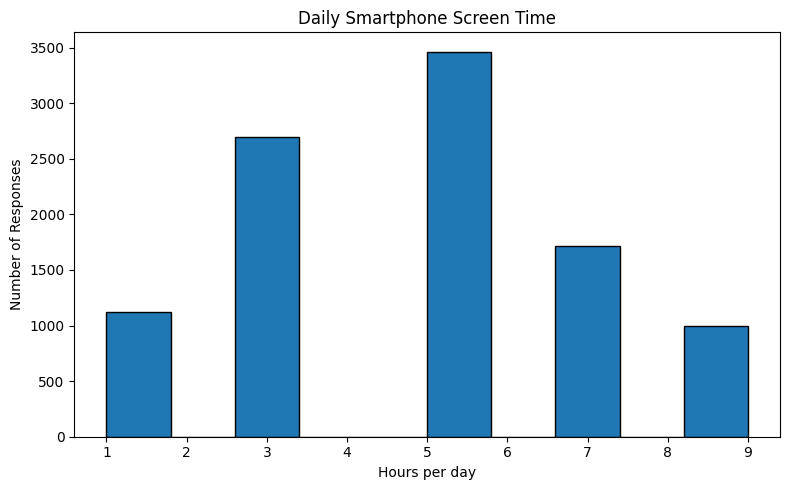

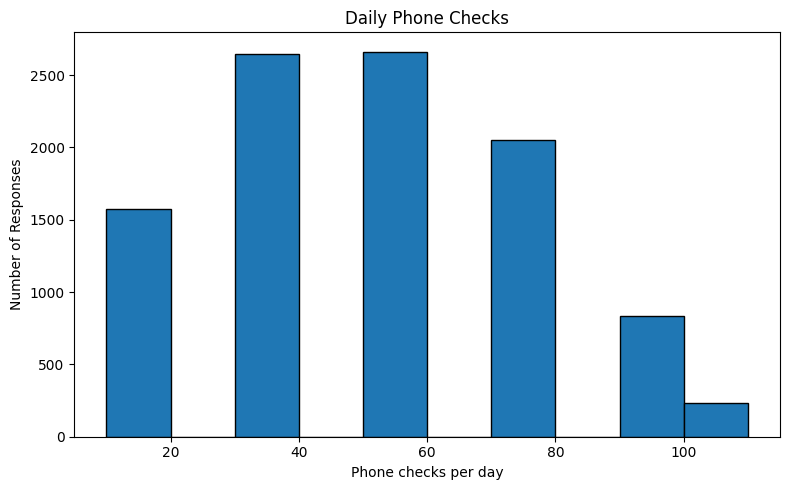

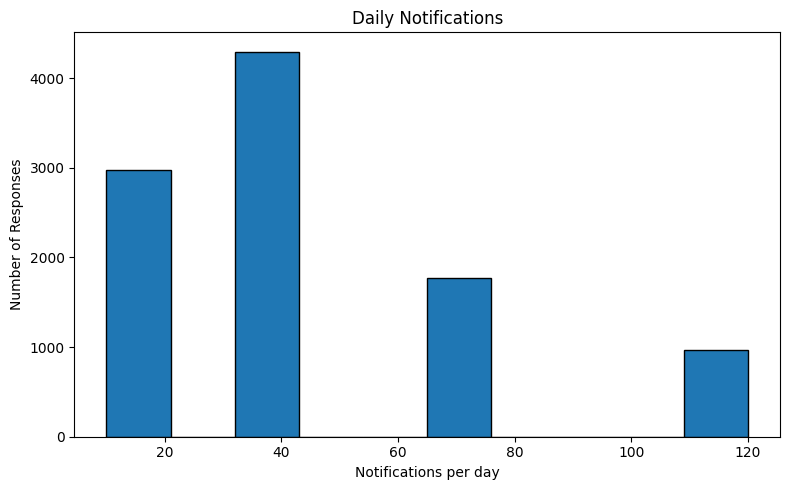

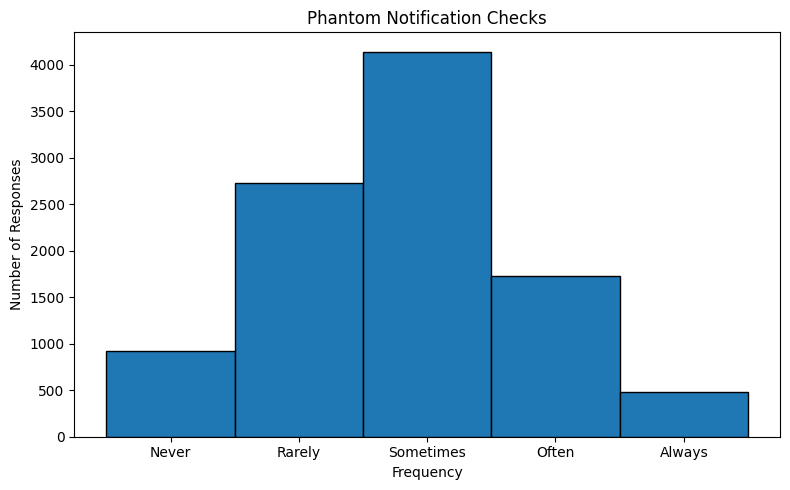

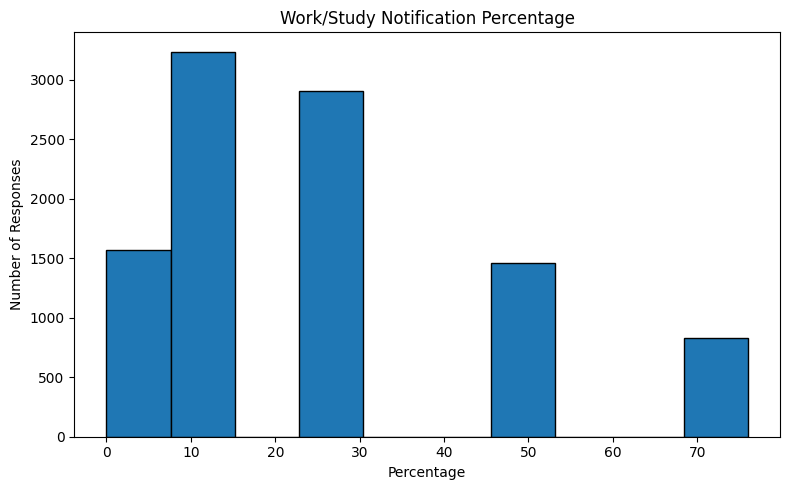

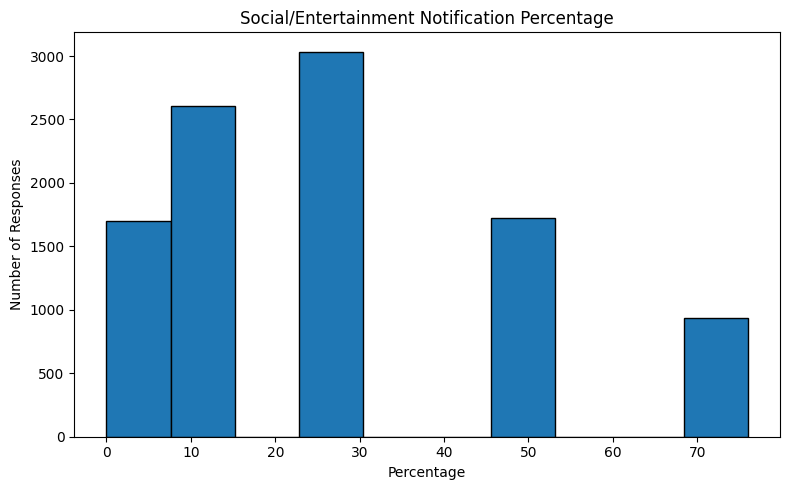

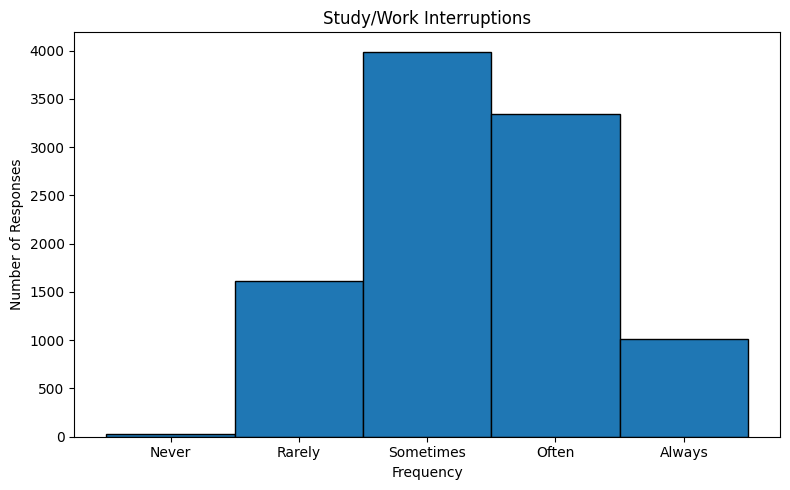

In [ ]:
import matplotlib.pyplot as plt

cols = [
    "screen_time_num",
    "phone_checks_num",
    "notifications_num",
    "phantom_check_num",
    "work_notification_pct_num",
    "social_notification_pct_num",
    "interruptions_num"
]

titles = [
    "Daily Smartphone Screen Time",
    "Daily Phone Checks",
    "Daily Notifications",
    "Phantom Notification Checks",
    "Work/Study Notification Percentage",
    "Social/Entertainment Notification Percentage",
    "Study/Work Interruptions"
]

xlabels = [
    "Hours per day",
    "Phone checks per day",
    "Notifications per day",
    "Frequency",
    "Percentage",
    "Percentage",
    "Frequency"
]

for col, title, xlabel in zip(cols, titles, xlabels):

    data = df[col].dropna()

    plt.figure(figsize=(8, 5))

    if col in ["phantom_check_num", "interruptions_num"]:
        plt.hist(
            data,
            bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5],
            edgecolor="black"
        )
        plt.xticks(
            [0, 1, 2, 3, 4],
            ["Never", "Rarely", "Sometimes", "Often", "Always"]
        )
    else:
        plt.hist(
            data,
            bins=10,
            edgecolor="black"
        )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Number of Responses")
    plt.tight_layout()
    plt.show()

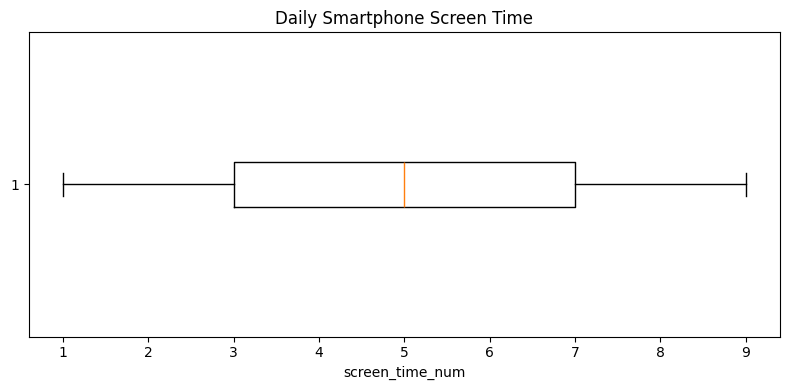

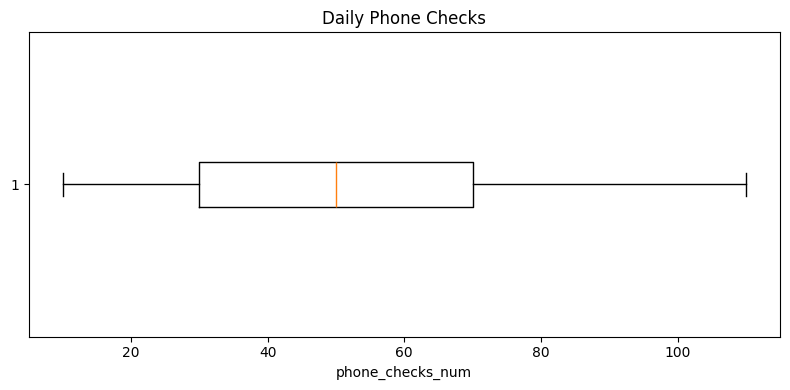

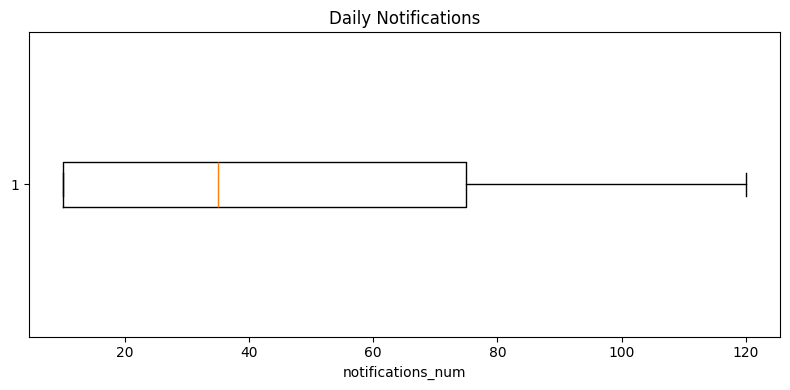

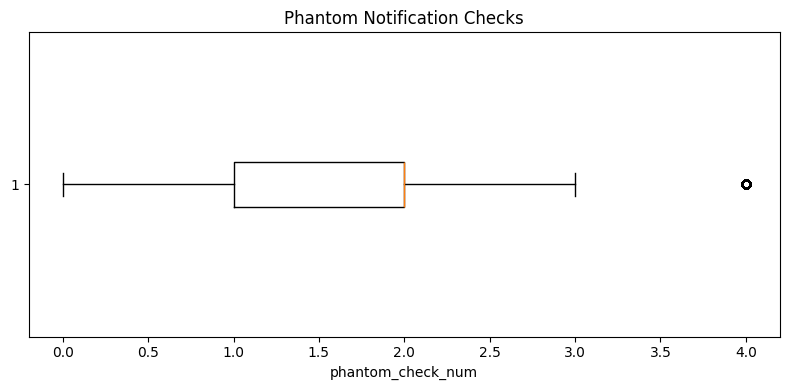

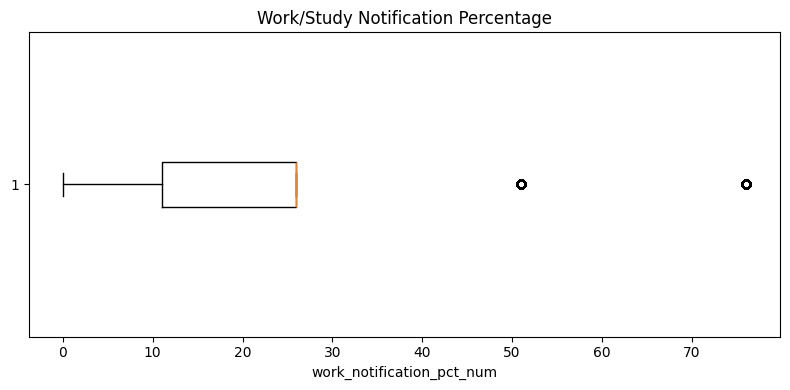

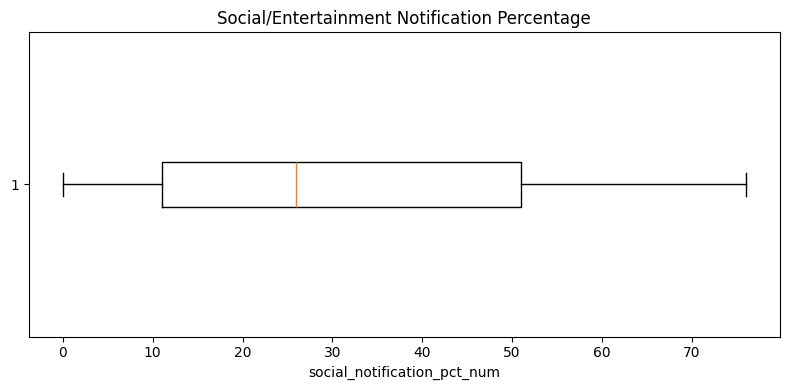

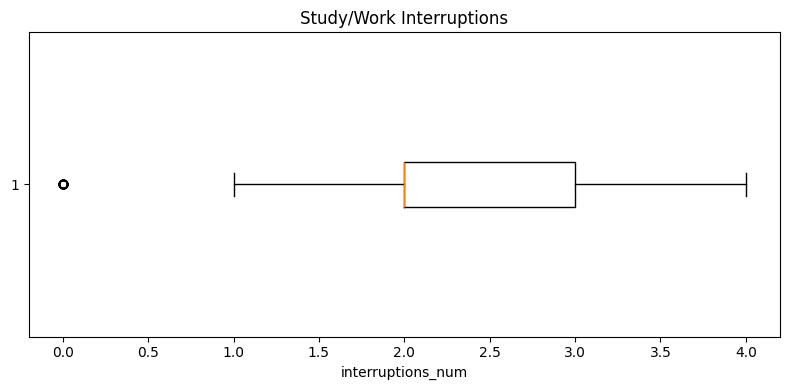

In [ ]:
import matplotlib.pyplot as plt

cols = [
    "screen_time_num",
    "phone_checks_num",
    "notifications_num",
    "phantom_check_num",
    "work_notification_pct_num",
    "social_notification_pct_num",
    "interruptions_num"
]

titles = [
    "Daily Smartphone Screen Time",
    "Daily Phone Checks",
    "Daily Notifications",
    "Phantom Notification Checks",
    "Work/Study Notification Percentage",
    "Social/Entertainment Notification Percentage",
    "Study/Work Interruptions"
]

for col, title in zip(cols, titles):

    data = df[col].dropna()

    plt.figure(figsize=(8, 4))

    plt.boxplot(
        data,
        vert=False
    )

    plt.title(title)
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

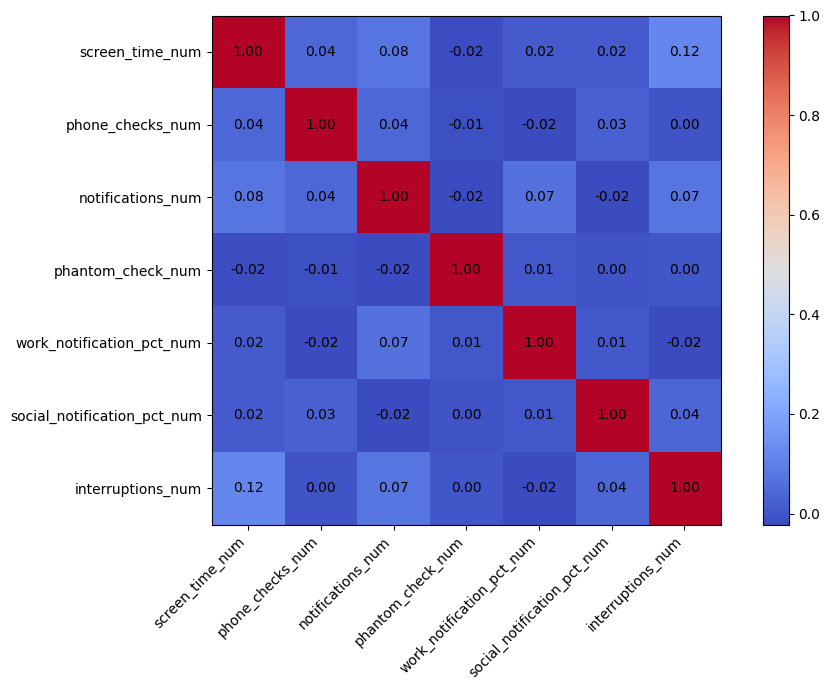

In [ ]:
corr = analysis_df.corr()

plt.figure(figsize=(10, 7))
plt.imshow(corr, cmap="coolwarm", interpolation="none")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center")

plt.tight_layout()
plt.show()

In [ ]:
print(corr.round(2))

                             screen_time_num  phone_checks_num  \
screen_time_num                         1.00              0.04   
phone_checks_num                        0.04              1.00   
notifications_num                       0.08              0.04   
phantom_check_num                      -0.02             -0.01   
work_notification_pct_num               0.02             -0.02   
social_notification_pct_num             0.02              0.03   
interruptions_num                       0.12              0.00   

                             notifications_num  phantom_check_num  \
screen_time_num                           0.08              -0.02   
phone_checks_num                          0.04              -0.01   
notifications_num                         1.00              -0.02   
phantom_check_num                        -0.02               1.00   
work_notification_pct_num                 0.07               0.01   
social_notification_pct_num              -0.02           

In [ ]:
cluster_features = [
    "screen_time_num",
    "phone_checks_num",
    "notifications_num",
    "phantom_check_num",
    "work_notification_pct_num",
    "social_notification_pct_num",
    "interruptions_num"
]

print(df[cluster_features].isna().sum())

screen_time_num                0
phone_checks_num               0
notifications_num              0
phantom_check_num              0
work_notification_pct_num      0
social_notification_pct_num    0
interruptions_num              0
dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

cluster_features = [
    "screen_time_num",
    "phone_checks_num",
    "notifications_num",
    "phantom_check_num",
    "work_notification_pct_num",
    "social_notification_pct_num",
    "interruptions_num"
]

print("Missing values:")
print(df[cluster_features].isna().sum())

X = df[cluster_features].dropna().copy()

print("\nData shape:", X.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled shape:", X_scaled.shape)
print("NaN values:", np.isnan(X_scaled).sum())

Missing values:
screen_time_num                0
phone_checks_num               0
notifications_num              0
phantom_check_num              0
work_notification_pct_num      0
social_notification_pct_num    0
interruptions_num              0
dtype: int64

Data shape: (10000, 7)
Scaled shape: (10000, 7)
NaN values: 0


In [ ]:
inertia = []

for k in range(2, 7):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_scaled)
    inertia.append(km.inertia_)

print(inertia)

[61984.26131582545, 55808.61834251822, 51017.63688964085, 47443.863076275265, 44556.04307201546]


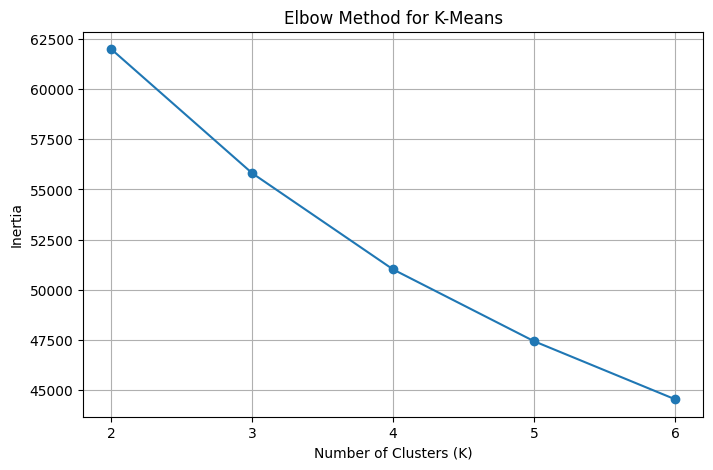

In [ ]:
import matplotlib.pyplot as plt

k_values = range(2, 7)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 7):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

    print(f"K={k}: Silhouette Score = {score:.4f}")

K=2: Silhouette Score = 0.1170
K=3: Silhouette Score = 0.1386
K=4: Silhouette Score = 0.1385
K=5: Silhouette Score = 0.1288
K=6: Silhouette Score = 0.1240


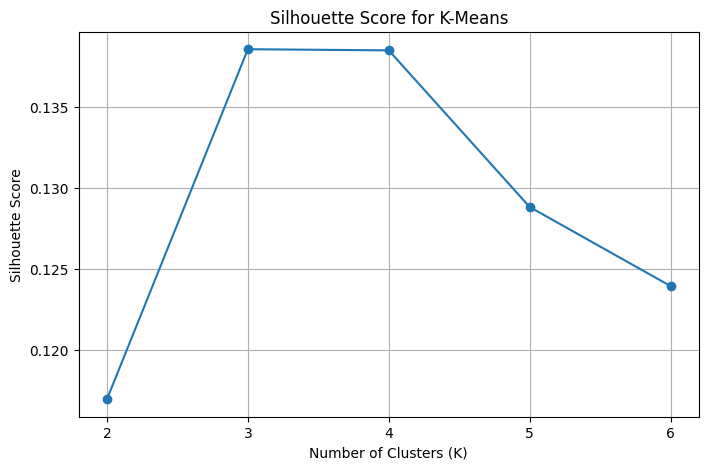

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for K-Means")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [ ]:
best_k = k_values[np.argmax(silhouette_scores)]
print("Best K based on silhouette score:", best_k)

Best K based on silhouette score: 3


In [ ]:
best_k = 2

final_km = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = final_km.fit_predict(X_scaled)

print("K:", best_k)
print("Clusters assigned successfully")

K: 2
Clusters assigned successfully


In [ ]:
df.loc[X.index, "persona_cluster"] = cluster_labels
df["persona_cluster"] = df["persona_cluster"].astype("Int64")
print(df["persona_cluster"].value_counts().sort_index())

persona_cluster
0    5375
1    4625
Name: count, dtype: Int64


In [ ]:
cluster_profile = (
    df.loc[X.index]
    .groupby("persona_cluster")[cluster_features]
    .mean()
)

print(cluster_profile.round(2))

                 screen_time_num  phone_checks_num  notifications_num  \
persona_cluster                                                         
0                           3.83             44.78              34.51   
1                           5.83             50.11              52.50   

                 phantom_check_num  work_notification_pct_num  \
persona_cluster                                                 
0                             1.82                      24.98   
1                             1.81                      24.76   

                 social_notification_pct_num  interruptions_num  
persona_cluster                                                  
0                                      23.86               1.79  
1                                      29.85               3.04  


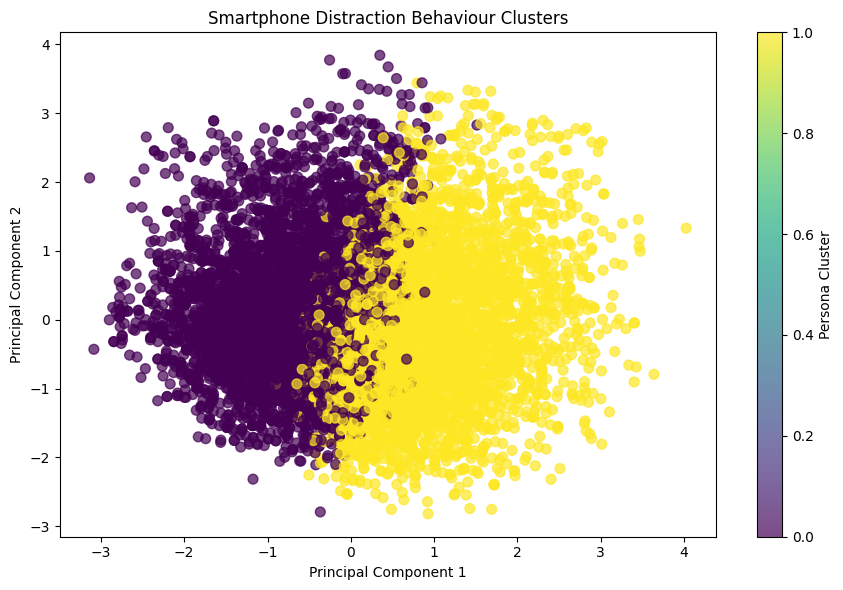

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    s=50,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Smartphone Distraction Behaviour Clusters")
plt.colorbar(label="Persona Cluster")

plt.tight_layout()
plt.show()

In [ ]:
cluster_counts = df.loc[X.index, "persona_cluster"].value_counts().sort_index()
print(cluster_counts)

persona_cluster
0    5375
1    4625
Name: count, dtype: Int64


In [ ]:
print(df["interruptions"].value_counts())

interruptions
Sometimes    3990
Often        3346
Rarely       1618
Always       1013
Never          33
Name: count, dtype: int64


In [ ]:
df["high_interruption"] = df["interruptions"].map({
    "Never": 0,
    "Rarely": 0,
    "Sometimes": 0,
    "Often": 1,
    "Always": 1
})

print(df["high_interruption"].value_counts())

high_interruption
0    5641
1    4359
Name: count, dtype: int64


In [ ]:
classification_features = [
    "screen_time_num",
    "phone_checks_num",
    "notifications_num",
    "phantom_check_num",
    "work_notification_pct_num",
    "social_notification_pct_num"
]

X_cls = df[classification_features].copy()
y_cls = df["high_interruption"].copy()

print(X_cls.shape)
print(y_cls.value_counts())

(10000, 6)
high_interruption
0    5641
1    4359
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

scaler_cls = StandardScaler()

X_train_scaled = scaler_cls.fit_transform(X_train)
X_test_scaled = scaler_cls.transform(X_test)

model = LogisticRegression(random_state=42)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Model trained successfully.")

Model trained successfully.


In [ ]:
print(y_cls.value_counts())

high_interruption
0    5641
1    4359
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.57
Precision: 0.511
Recall   : 0.32
F1 Score : 0.3935

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.76      0.67      1128
           1       0.51      0.32      0.39       872

    accuracy                           0.57      2000
   macro avg       0.55      0.54      0.53      2000
weighted avg       0.56      0.57      0.55      2000



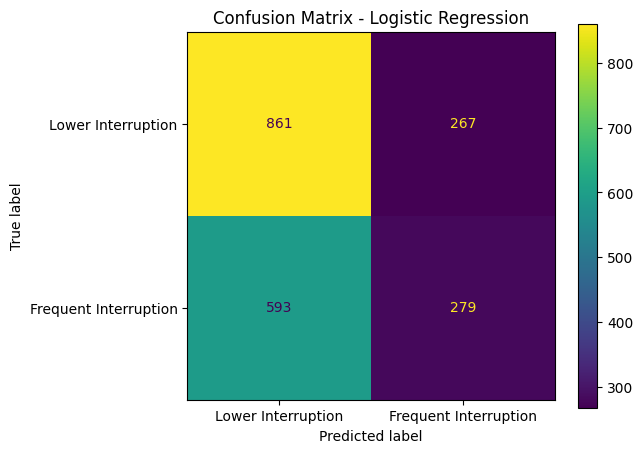

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Lower Interruption", "Frequent Interruption"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest")
print("Accuracy :", round(accuracy_score(y_test, rf_pred), 4))
print("Precision:", round(precision_score(y_test, rf_pred), 4))
print("Recall   :", round(recall_score(y_test, rf_pred), 4))
print("F1 Score :", round(f1_score(y_test, rf_pred), 4))

Random Forest
Accuracy : 0.581
Precision: 0.5213
Recall   : 0.4771
F1 Score : 0.4982


report

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, y_pred), accuracy_score(y_test, rf_pred)],
    "Precision": [precision_score(y_test, y_pred), precision_score(y_test, rf_pred)],
    "Recall": [recall_score(y_test, y_pred), recall_score(y_test, rf_pred)],
    "F1 Score": [f1_score(y_test, y_pred), f1_score(y_test, rf_pred)]
})

print(results.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression     0.570     0.5110  0.3200    0.3935
1        Random Forest     0.581     0.5213  0.4771    0.4982


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": classification_features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(feature_importance)

                       Feature  Importance
1             phone_checks_num    0.243021
4    work_notification_pct_num    0.195729
3            phantom_check_num    0.165733
5  social_notification_pct_num    0.153041
0              screen_time_num    0.142840
2            notifications_num    0.099636


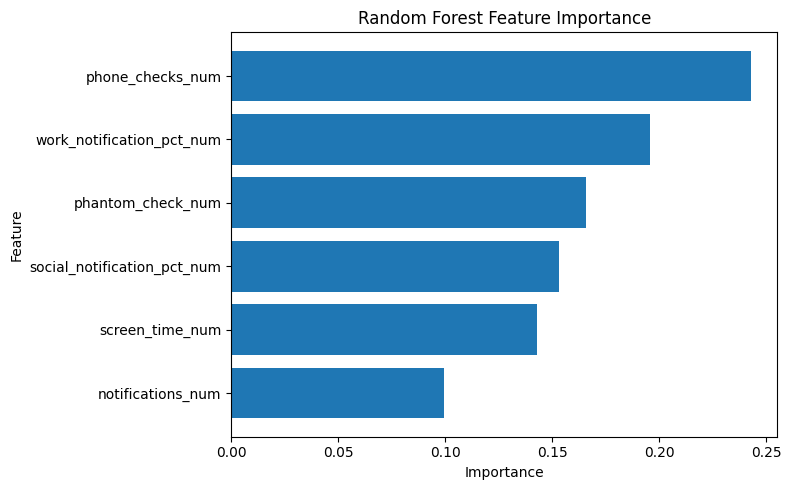

In [ ]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

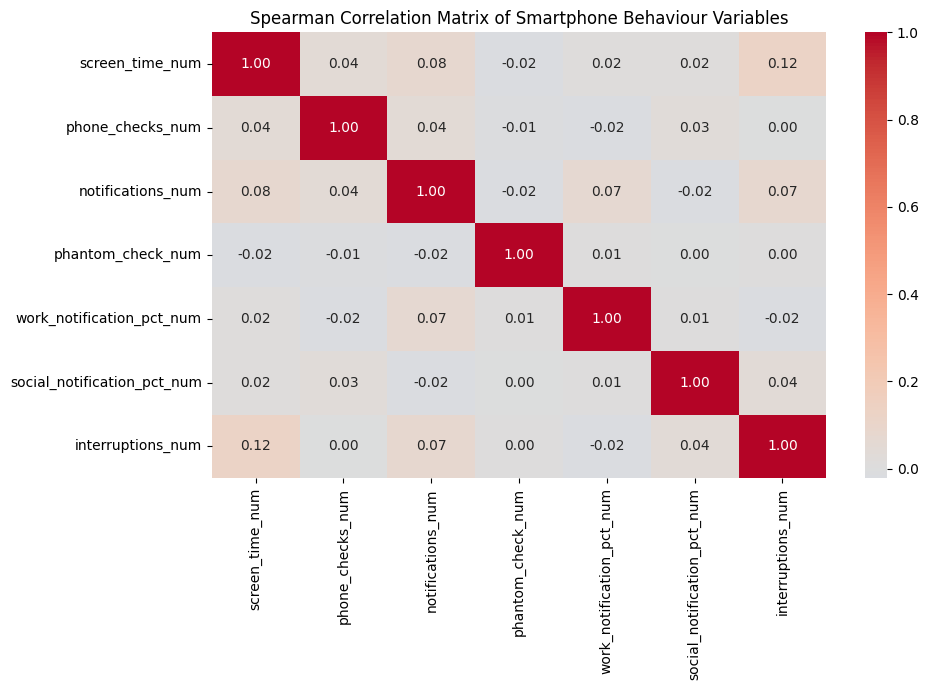

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Spearman Correlation Matrix of Smartphone Behaviour Variables")
plt.tight_layout()
plt.show()

In [ ]:
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)

print(corr_pairs.head(10).round(3))

screen_time_num              interruptions_num              0.121
                             notifications_num              0.077
notifications_num            interruptions_num              0.075
                             work_notification_pct_num      0.066
phone_checks_num             notifications_num              0.043
screen_time_num              phone_checks_num               0.042
social_notification_pct_num  interruptions_num              0.039
phone_checks_num             social_notification_pct_num    0.027
work_notification_pct_num    interruptions_num             -0.022
notifications_num            social_notification_pct_num   -0.021
dtype: float64


In [ ]:
cluster_summary = (
    df.loc[X.index, "persona_cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("Persona Cluster")
    .reset_index(name="Respondents")
)

cluster_summary["Percentage"] = (
    cluster_summary["Respondents"] / len(X) * 100
).round(2)

print(cluster_summary)

   Persona Cluster  Respondents  Percentage
0                0         5375       53.75
1                1         4625       46.25


In [ ]:
summary = df[cluster_features].describe().T

summary = summary[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
].round(2)

print(summary)

                               count   mean    std   min   25%   50%   75%  \
screen_time_num              10000.0   4.75   2.26   1.0   3.0   5.0   7.0   
phone_checks_num             10000.0  47.24  25.49  10.0  30.0  50.0  70.0   
notifications_num            10000.0  42.83  33.21  10.0  10.0  35.0  75.0   
phantom_check_num            10000.0   1.81   0.98   0.0   1.0   2.0   2.0   
work_notification_pct_num    10000.0  24.88  21.84   0.0  11.0  26.0  26.0   
social_notification_pct_num  10000.0  26.63  22.67   0.0  11.0  26.0  51.0   
interruptions_num            10000.0   2.37   0.88   0.0   2.0   2.0   3.0   

                               max  
screen_time_num                9.0  
phone_checks_num             110.0  
notifications_num            120.0  
phantom_check_num              4.0  
work_notification_pct_num     76.0  
social_notification_pct_num   76.0  
interruptions_num              4.0  


In [ ]:
cluster_summary = (
    df["persona_cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("Persona Cluster")
    .reset_index(name="Respondents")
)

cluster_summary["Percentage"] = (
    cluster_summary["Respondents"] / len(X) * 100
).round(2)

cluster_summary

,Persona Cluster,Respondents,Percentage
0,0,5375,53.75
1,1,4625,46.25


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": classification_features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
1,phone_checks_num,0.243021
4,work_notification_pct_num,0.195729
3,phantom_check_num,0.165733
5,social_notification_pct_num,0.153041
0,screen_time_num,0.142840
2,notifications_num,0.099636


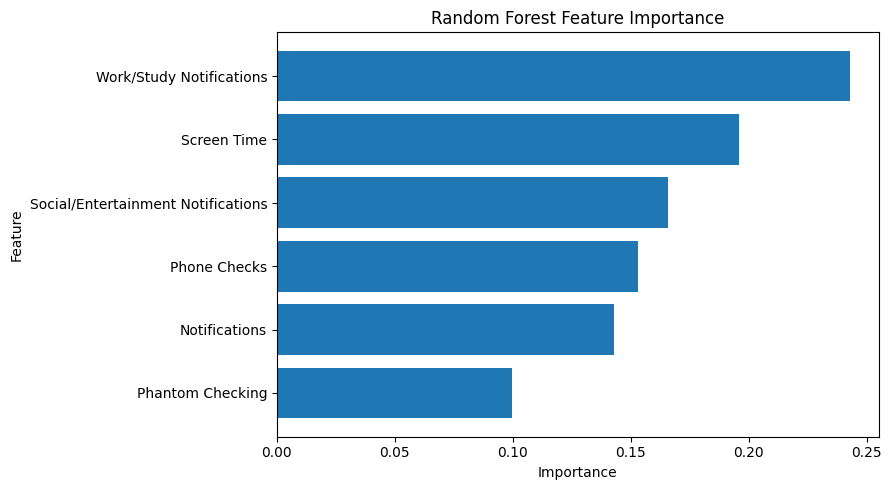

In [ ]:
plot_labels = [
    "Work/Study Notifications",
    "Screen Time",
    "Social/Entertainment Notifications",
    "Phone Checks",
    "Notifications",
    "Phantom Checking"
]

plt.figure(figsize=(9, 5))

plt.barh(
    plot_labels,
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

save training

In [ ]:
import joblib

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

joblib.dump(clf, "smartphone_distraction_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [ ]:
joblib.dump(
    clf,
    "/content/drive/MyDrive/smartphone_distraction_model.pkl"
)

print("Model saved to Google Drive.")

Model saved to Google Drive.


In [ ]:
import joblib
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_features = [
    "screen_time_num",
    "phone_checks_num",
    "notifications_num",
    "phantom_check_num",
    "work_notification_pct_num",
    "social_notification_pct_num",
    "interruptions_num"
]

X = df[cluster_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

print("K-Means model trained successfully.")

K-Means model trained successfully.


In [ ]:
joblib.dump(
    scaler,
    "/content/drive/MyDrive/smartphone_persona_scaler.pkl"
)

joblib.dump(
    kmeans,
    "/content/drive/MyDrive/smartphone_persona_kmeans.pkl"
)

print("Scaler and K-Means model saved successfully.")

Scaler and K-Means model saved successfully.


In [ ]:
df["cluster"] = kmeans.labels_

In [ ]:
df.groupby("cluster")[num_cols].mean().round(2)

,screen_time_num,phone_checks_num,notifications_num,phantom_check_num,work_notification_pct_num,social_notification_pct_num,interruptions_num
cluster,,,,,,,
0,3.83,44.78,34.51,1.82,24.98,23.86,1.79
1,5.83,50.11,52.50,1.81,24.76,29.85,3.04


testing

In [259]:
import joblib
import pandas as pd
import numpy as np

In [260]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [261]:
scaler = joblib.load("/content/drive/MyDrive/smartphone_persona_scaler.pkl")
kmeans = joblib.load("/content/drive/MyDrive/smartphone_persona_kmeans.pkl")

In [262]:
screen_time = float(input("Daily smartphone usage (hours): "))
phone_checks = float(input("Daily phone checks: "))
notifications = float(input("Daily notifications: "))
phantom_check = int(input("Phantom checking frequency (1-5): "))
work_pct = float(input("Work/study notification percentage: "))
social_pct = float(input("Social/entertainment notification percentage: "))
interruptions = int(input("Study/work interruption frequency (1-5): "))

Daily smartphone usage (hours): 10
Daily phone checks: 30
Daily notifications: 10
Phantom checking frequency (1-5): 4
Work/study notification percentage: 30
Social/entertainment notification percentage: 60
Study/work interruption frequency (1-5): 4


In [263]:
screen_map = {
    "Less than 2 hours": 1,
    "2–4 hours": 3,
    "4–6 hours": 5,
    "6–8 hours": 7,
    "More than 8 hours": 9
}

checks_map = {
    "Less than 20": 10,
    "20–40": 30,
    "41–60": 50,
    "61–80": 70,
    "81–100": 90,
    "More than 100": 110
}

notif_map = {
    "Less than 20": 10,
    "20–50": 35,
    "51–100": 75,
    "More than 100": 125
}

phantom_map = {
    "Never": 1,
    "Rarely": 2,
    "Sometimes": 3,
    "Often": 4,
    "Always": 5
}

pct_map = {
    "0–10%": 5,
    "11–25%": 18,
    "26–50%": 38,
    "51–75%": 63,
    "76–100%": 88
}

interruption_map = {
    "Never": 1,
    "Rarely": 2,
    "Sometimes": 3,
    "Often": 4,
    "Always": 5
}

In [264]:
new_user = pd.DataFrame([{
    "screen_time_num": screen_time,
    "phone_checks_num": phone_checks,
    "notifications_num": notifications,
    "phantom_check_num": phantom_check,
    "work_notification_pct_num": work_pct,
    "social_notification_pct_num": social_pct,
    "interruptions_num": interruptions
}])

In [265]:
new_user_scaled = scaler.transform(new_user)

prediction = kmeans.predict(new_user_scaled)[0]

cluster_names = {
    0: "Cluster 0 – Lower Smartphone Distraction",
    1: "Cluster 1 – Higher Smartphone Distraction"
}

print(f"Predicted Group: {cluster_names[prediction]}")

Predicted Group: Cluster 1 – Higher Smartphone Distraction
